# EDA — Modelo de Predicción Mundial 2026

Este notebook documenta el análisis exploratorio del dataset construido por
el pipeline `repository/src/features/features.py`. Cada sección produce
visualizaciones y estadísticas que justifican las decisiones de modelado
y alimentan el reporte técnico final.

**Estructura**
1. Setup
2. Inventario de fuentes
3. Calidad de datos
4. Distribución del target
5. Análisis univariado de cada feature
6. Correlaciones
7. ELO histórico (sanity check)
8. SHAP — importancia de variables
9. Limitaciones del dataset
10. Resumen


## 1. Setup


In [1]:
import os
import sys
from pathlib import Path

# CWD = repository/
_repo_root = Path.cwd()
if _repo_root.name == "notebooks":
    os.chdir(_repo_root.parent)
    _repo_root = Path.cwd()
sys.path.insert(0, str(_repo_root))

print(f"CWD: {_repo_root}")


CWD: c:\Users\david\Desktop\fifa-world-cup-model\repository


In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)
sns.set_palette("colorblind")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["savefig.dpi"] = 150
plt.rcParams["savefig.bbox"] = "tight"

FIG_DIR = Path("reports") / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)


def savefig(name: str):
    out = FIG_DIR / f"eda_{name}.png"
    plt.savefig(out)
    print(f"  → {out}")


from src.models.train import FEATURE_COLS
from src.features.time_decay import REFERENCE_DATE, lambda_to_halflife_years
print(f"FEATURE_COLS = {FEATURE_COLS}")
print(f"REFERENCE_DATE = {REFERENCE_DATE.date()}")


FEATURE_COLS = ['elo_diff', 'squad_value_diff', 'xg_avg_for', 'xg_avg_against', 'travel_distance_home', 'travel_distance_away', 'ranking_diff']
REFERENCE_DATE = 2026-01-01


## 2. Inventario de fuentes de datos

Las 5 fuentes que alimentan el pipeline. Documentamos volumetría, rango
temporal y cobertura de equipos.


In [3]:
from src.data.data_loader import (
    load_international_results, load_fifa_ranking, load_wc2026_fixture,
    filter_relevant_matches,
)
from src.data.scraper import (
    get_statsbomb_xg_by_team, get_squad_values, SQUAD_VALUES_SNAPSHOT_DATE,
)

# 1. International results (1872 -> hoy)
results_raw = load_international_results()
print(f"international_results: {len(results_raw):,} filas, "
      f"{results_raw['date'].dt.year.min()}–{results_raw['date'].dt.year.max()}")

# 2. FIFA ranking
fifa = load_fifa_ranking()
print(f"fifa_ranking: {len(fifa):,} filas, {fifa['team'].nunique()} equipos únicos")

# 3. Fixture WC 2026
fixture = load_wc2026_fixture()
print(f"wc2026_fixture: {len(fixture)} equipos en {fixture['group'].nunique()} grupos")

# 4. xG StatsBomb (cache; no llama API si ya existe el CSV)
try:
    xg = get_statsbomb_xg_by_team()
    print(f"statsbomb_xg: {len(xg)} equipos con xG")
except Exception as e:
    print(f"statsbomb_xg no disponible: {e}")
    xg = pd.DataFrame()

# 5. Squad values
squad = get_squad_values()
print(f"squad_values: {len(squad)} equipos (snapshot {SQUAD_VALUES_SNAPSHOT_DATE})")


international_results: 49,329 filas, 1872–2026
fifa_ranking: 67,472 filas, 216 equipos únicos
wc2026_fixture: 48 equipos en 12 grupos
statsbomb_xg: 109 equipos con xG
  squad_values.csv cargado desde caché (62 equipos)
squad_values: 62 equipos (snapshot 2026-05)


In [4]:
inventory = pd.DataFrame([
    {"fuente": "international_results", "filas": len(results_raw),
     "rango": f"{results_raw['date'].dt.year.min()}-{results_raw['date'].dt.year.max()}",
     "equipos": pd.concat([results_raw['home_team'], results_raw['away_team']]).nunique()},
    {"fuente": "fifa_ranking", "filas": len(fifa), "rango": "1992-2024", "equipos": fifa['team'].nunique()},
    {"fuente": "wc2026_fixture", "filas": len(fixture), "rango": "2026", "equipos": fixture['team'].nunique()},
    {"fuente": "statsbomb_xg", "filas": len(xg), "rango": "UEFA/FIFA OpenData", "equipos": len(xg)},
    {"fuente": "squad_values", "filas": len(squad), "rango": SQUAD_VALUES_SNAPSHOT_DATE, "equipos": len(squad)},
])
inventory


,fuente,filas,rango,equipos
0,international_results,49329,1872-2026,336
1,fifa_ranking,67472,1992-2024,216
2,wc2026_fixture,48,2026,48
3,statsbomb_xg,109,UEFA/FIFA OpenData,109
4,squad_values,62,2026-05,62


## 3. Calidad de datos

Nulos, duplicados, cobertura por torneo y por equipo.


In [5]:
from src.features.features import data_quality_report
data_quality_report(results_raw, "international_results crudo")



=== Data quality report: international_results crudo ===
  Filas: 49,329
  Columnas: ['date', 'home_team', 'away_team', 'home_score', 'away_score', 'tournament', 'city', 'country', 'neutral']
  Nulos por columna:
    home_score: 72
    away_score: 72
  Duplicados exactos: 0
  Rango de fechas: 1872-11-30 → 2026-06-27
  Equipos únicos en home_team: 327
  Equipos únicos en away_team: 321



In [6]:
# Filtrado al subset que usa el modelo
results = filter_relevant_matches(results_raw, year_cutoff=1990)
data_quality_report(results, "international_results filtrado")



=== Data quality report: international_results filtrado ===
  Filas: 12,640
  Columnas: ['date', 'home_team', 'away_team', 'home_score', 'away_score', 'tournament', 'city', 'country', 'neutral']
  Nulos por columna:
    home_score: 72
    away_score: 72
  Duplicados exactos: 0
  Rango de fechas: 1990-05-30 → 2026-06-27
  Equipos únicos en home_team: 219
  Equipos únicos en away_team: 219



  → reports\figures\eda_03_top_tournaments.png


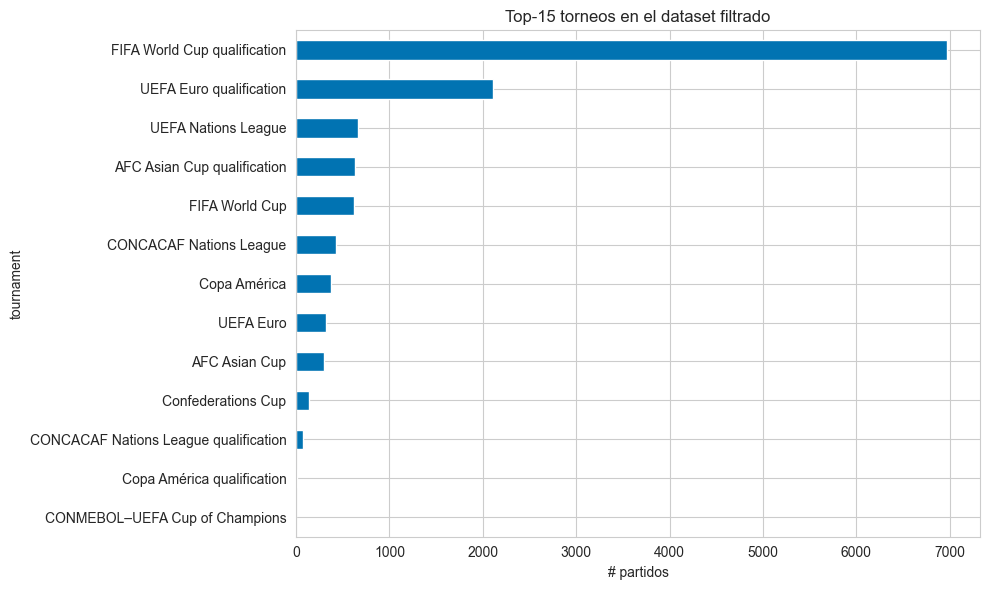

In [7]:
# Distribución por torneo (top 15)
top_tournaments = results['tournament'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(10, 6))
top_tournaments.plot(kind='barh', ax=ax)
ax.invert_yaxis()
ax.set_xlabel("# partidos")
ax.set_title("Top-15 torneos en el dataset filtrado")
plt.tight_layout()
savefig("03_top_tournaments")
plt.show()


  → reports\figures\eda_03_matches_per_year.png


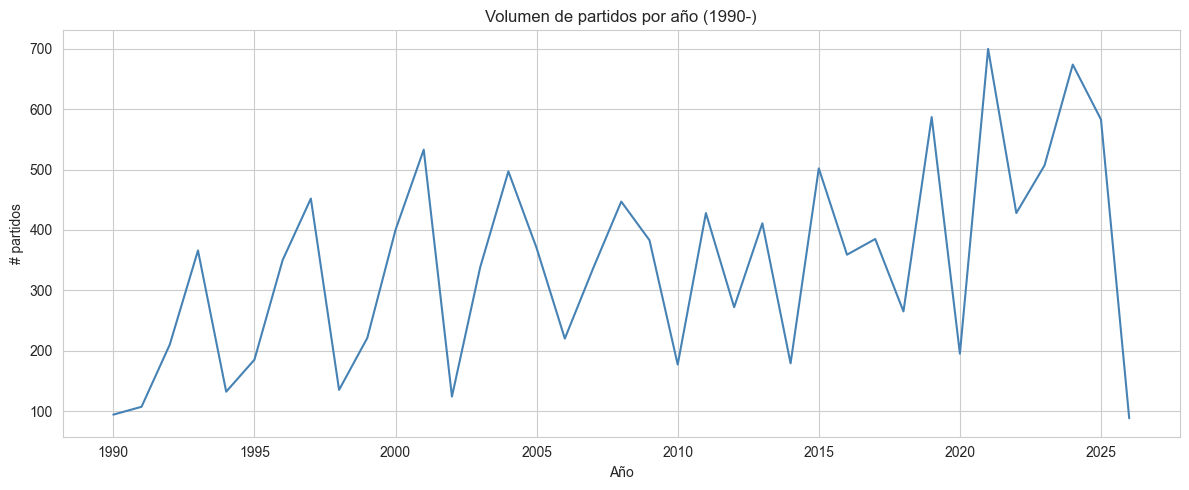

In [8]:
# Distribución de partidos por año
fig, ax = plt.subplots(figsize=(12, 5))
results.groupby(results['date'].dt.year).size().plot(ax=ax, color='steelblue')
ax.set_xlabel("Año")
ax.set_ylabel("# partidos")
ax.set_title("Volumen de partidos por año (1990-)")
plt.tight_layout()
savefig("03_matches_per_year")
plt.show()


In [9]:
# Cobertura por equipo
team_counts = pd.concat([results['home_team'], results['away_team']]).value_counts()
print(f"Total equipos en el dataset filtrado: {len(team_counts)}")
print(f"\nTop-10 equipos con más partidos:")
print(team_counts.head(10).to_string())
print(f"\nBottom-10 equipos con menos partidos:")
print(team_counts.tail(10).to_string())


Total equipos en el dataset filtrado: 219

Top-10 equipos con más partidos:
Spain          289
Italy          284
Argentina      281
Brazil         276
Germany        274
Portugal       272
Netherlands    268
France         264
Uruguay        264
Mexico         260

Bottom-10 equipos con menos partidos:
Tonga                    20
Comoros                  20
Martinique               20
São Tomé and Príncipe    20
Cook Islands             18
Vanuatu                  17
American Samoa           15
South Sudan              14
Yugoslavia               13
Eritrea                  10


## 4. Distribución del target

Confirmar el desbalance Home / Draw / Away que motiva `class_weight="balanced"`.


In [10]:
features = pd.read_csv("data/processed/features.csv", parse_dates=["date"])
print(f"features.csv: {len(features):,} filas, columnas {list(features.columns)}")
features.head()


features.csv: 12,157 filas, columnas ['date', 'home_team', 'away_team', 'elo_diff', 'squad_value_diff', 'xg_avg_for', 'xg_avg_against', 'travel_distance_home', 'travel_distance_away', 'ranking_diff', 'time_weight', 'target']


,date,home_team,away_team,elo_diff,squad_value_diff,xg_avg_for,xg_avg_against,travel_distance_home,travel_distance_away,ranking_diff,time_weight,target
0,1993-01-10,Angola,Zimbabwe,0.0,0.000000,0.000000,0.000000,0.000000,1496.776417,-48.0,3.457121e-11,1
1,1993-01-10,DR Congo,Cameroon,0.0,-0.280622,0.177752,-0.647610,329.959053,1257.757481,-56.0,3.457121e-11,0
2,1993-01-16,South Africa,Nigeria,0.0,-1.114924,0.073391,-0.165729,0.000000,4496.002705,-111.0,3.498856e-11,1
3,1993-01-16,Tanzania,Zambia,0.0,0.000000,0.000000,0.000000,0.000000,1264.116820,-48.0,3.498856e-11,0
4,1993-01-17,Benin,Tunisia,0.0,0.801218,-0.032790,-0.642709,0.000000,3137.393419,-89.0,3.505861e-11,0


   clase  count   pct
Away Win   3722 30.62
    Draw   2542 20.91
Home Win   5893 48.47
  → reports\figures\eda_04_target_distribution.png


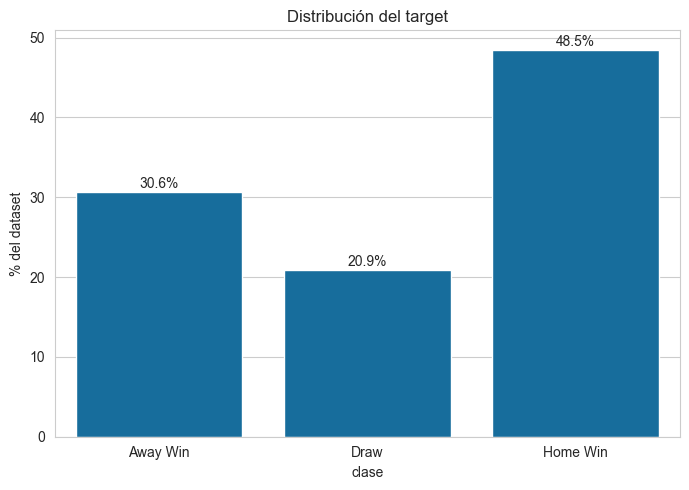

In [11]:
target_map = {0: "Away Win", 1: "Draw", 2: "Home Win"}
target_counts = features['target'].value_counts().sort_index()
target_pct = (target_counts / target_counts.sum() * 100).round(2)
dist = pd.DataFrame({"clase": [target_map[i] for i in target_counts.index],
                     "count": target_counts.values, "pct": target_pct.values})
print(dist.to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 5))
sns.barplot(data=dist, x='clase', y='pct', ax=ax)
for i, v in enumerate(dist['pct']):
    ax.text(i, v + 0.5, f"{v:.1f}%", ha='center')
ax.set_ylabel("% del dataset")
ax.set_title("Distribución del target")
plt.tight_layout()
savefig("04_target_distribution")
plt.show()


**Lectura:** el dataset es claramente desbalanceado — la clase mayoritaria
(Home Win) duplica a Draw. Esto justifica el uso de `class_weight="balanced"` y
penaliza el reportar accuracy bruta como métrica principal.


## 5. Análisis univariado por feature

Para cada feature: distribución global, separación por clase, comentario.


In [12]:
def plot_feature_distribution(df, feature, name_slug):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    df_plot = df.copy()
    df_plot['Resultado'] = df_plot['target'].map(target_map)

    sns.histplot(data=df_plot, x=feature, hue='Resultado',
                 kde=True, bins=40, ax=axes[0], alpha=0.5)
    axes[0].set_title(f"Distribución de {feature} por resultado")

    sns.boxplot(data=df_plot, x='Resultado', y=feature,
                order=["Away Win", "Draw", "Home Win"], ax=axes[1])
    axes[1].set_title(f"{feature} por clase (boxplot)")

    plt.tight_layout()
    savefig(f"05_{name_slug}")
    plt.show()
    print(df[feature].describe().round(3).to_string())


### 5.1 `elo_diff`

  → reports\figures\eda_05_elo_diff.png


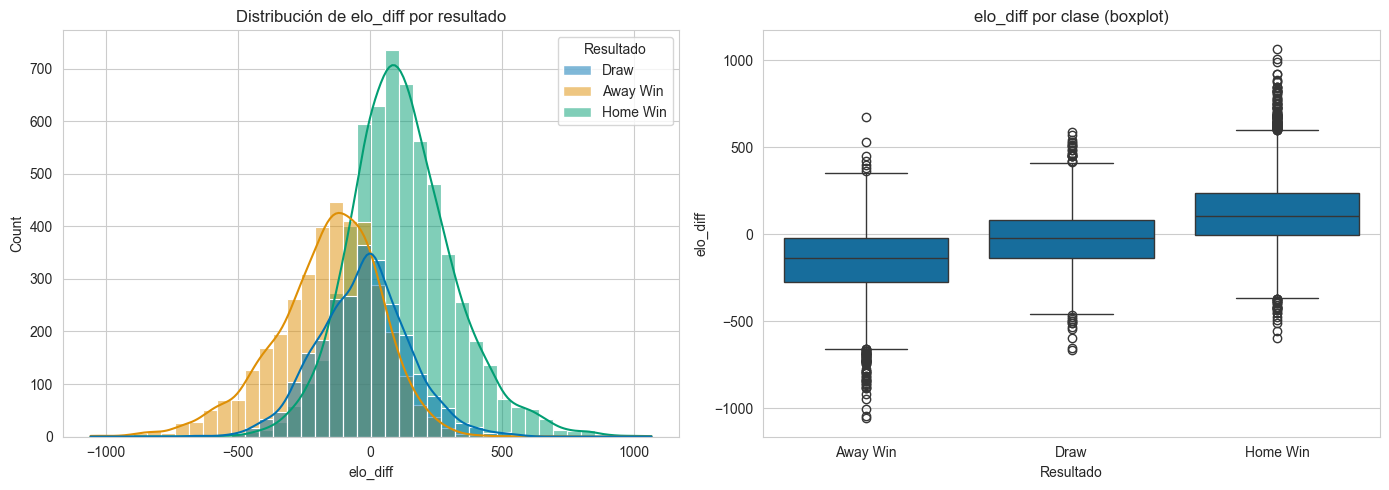

count    12157.000
mean         4.628
std        229.613
min      -1058.050
25%       -132.106
50%          4.688
75%        143.013
max       1066.620


In [13]:
plot_feature_distribution(features, 'elo_diff', 'elo_diff')

ELO suele ser el feature con mejor separación entre clases. Valores muy positivos correlacionan con victoria del local.

### 5.2 `squad_value_diff`

  → reports\figures\eda_05_squad_value_diff.png


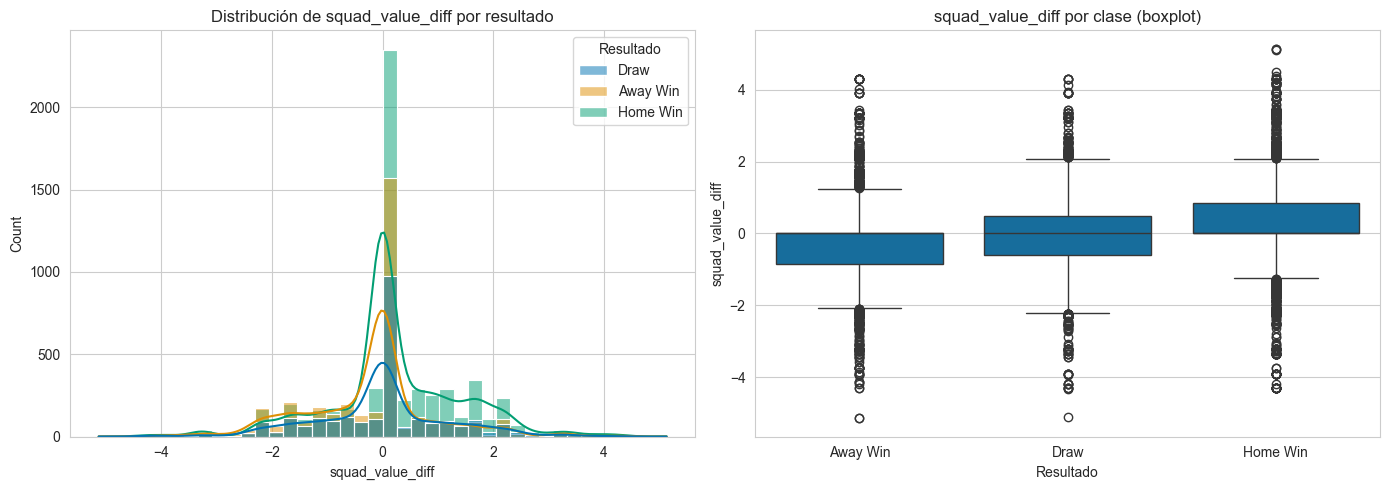

count    12157.000
mean         0.026
std          1.225
min         -5.135
25%         -0.446
50%          0.000
75%          0.533
max          5.135


In [14]:
plot_feature_distribution(features, 'squad_value_diff', 'squad_value_diff')

### 5.3 `xg_avg_for`

  → reports\figures\eda_05_xg_avg_for.png


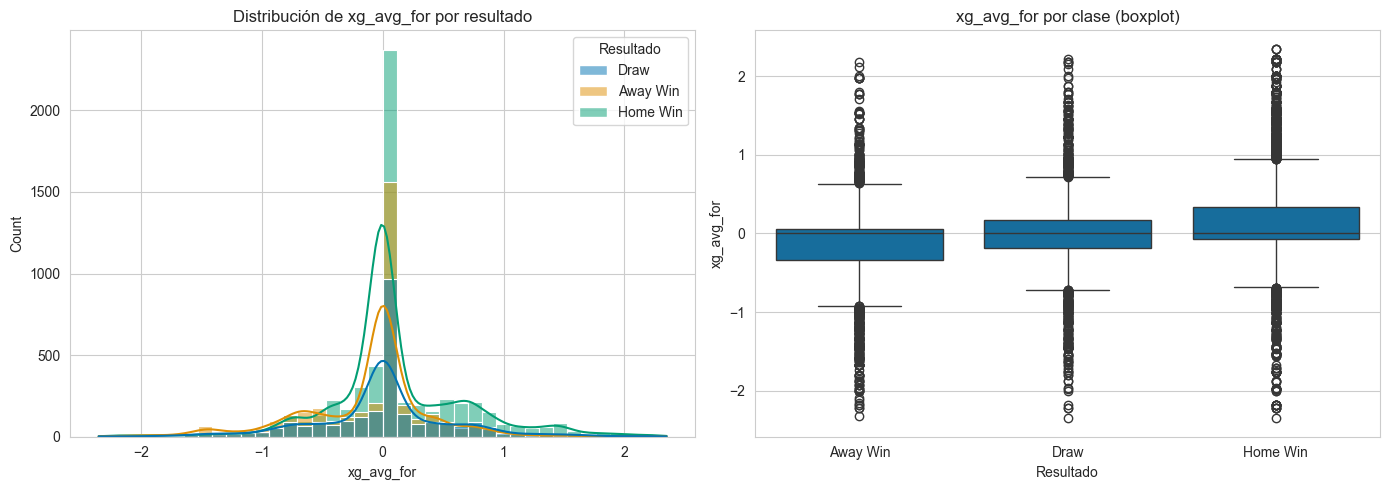

count    12157.000
mean         0.014
std          0.565
min         -2.348
25%         -0.155
50%          0.000
75%          0.172
max          2.348


In [15]:
plot_feature_distribution(features, 'xg_avg_for', 'xg_avg_for')

### 5.4 `xg_avg_against`

  → reports\figures\eda_05_xg_avg_against.png


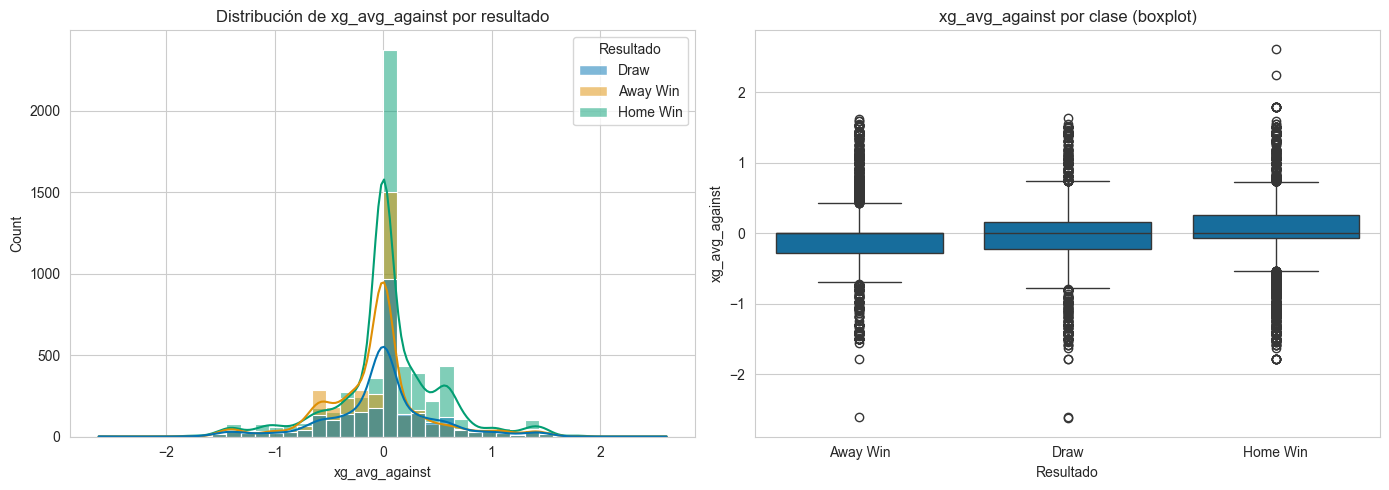

count    12157.000
mean        -0.007
std          0.496
min         -2.625
25%         -0.177
50%          0.000
75%          0.156
max          2.613


In [16]:
plot_feature_distribution(features, 'xg_avg_against', 'xg_avg_against')

### 5.5 `travel_distance_home` y `travel_distance_away`

travel_distance_home == 0 (campo neutral / sin geocoding): 97.7%
travel_distance_away == 0: 18.7%
  → reports\figures\eda_05_travel_distance_home.png


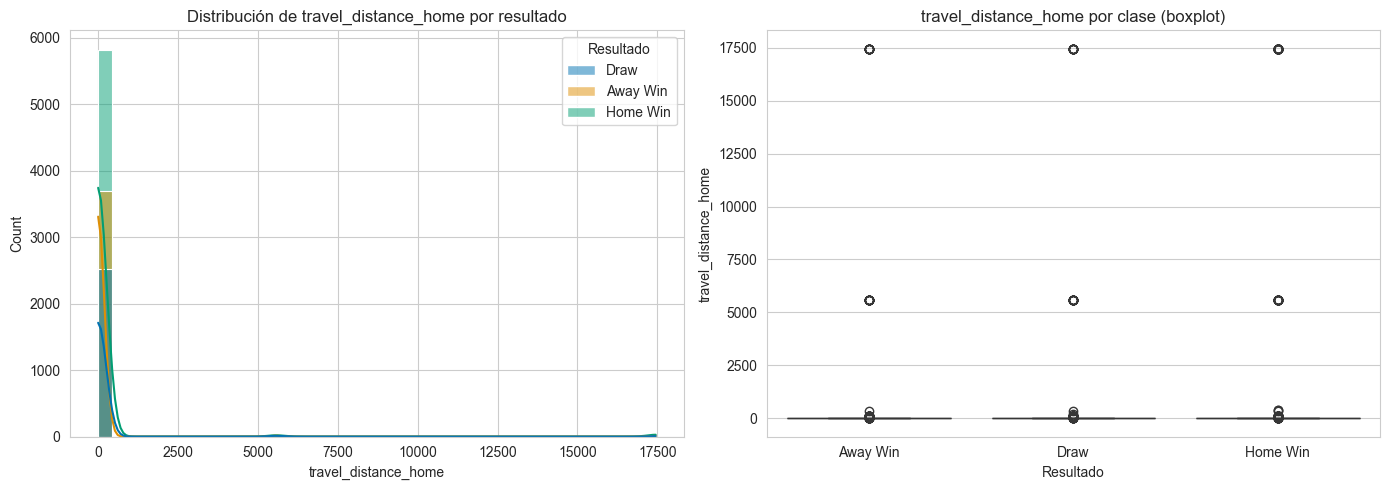

count    12157.000
mean       121.664
std       1329.333
min          0.000
25%          0.000
50%          0.000
75%          0.000
max      17450.738


In [17]:
print("travel_distance_home == 0 (campo neutral / sin geocoding):",
      f"{(features['travel_distance_home'] == 0).mean()*100:.1f}%")
print("travel_distance_away == 0:",
      f"{(features['travel_distance_away'] == 0).mean()*100:.1f}%")
plot_feature_distribution(features, 'travel_distance_home', 'travel_distance_home')


  → reports\figures\eda_05_travel_distance_away.png


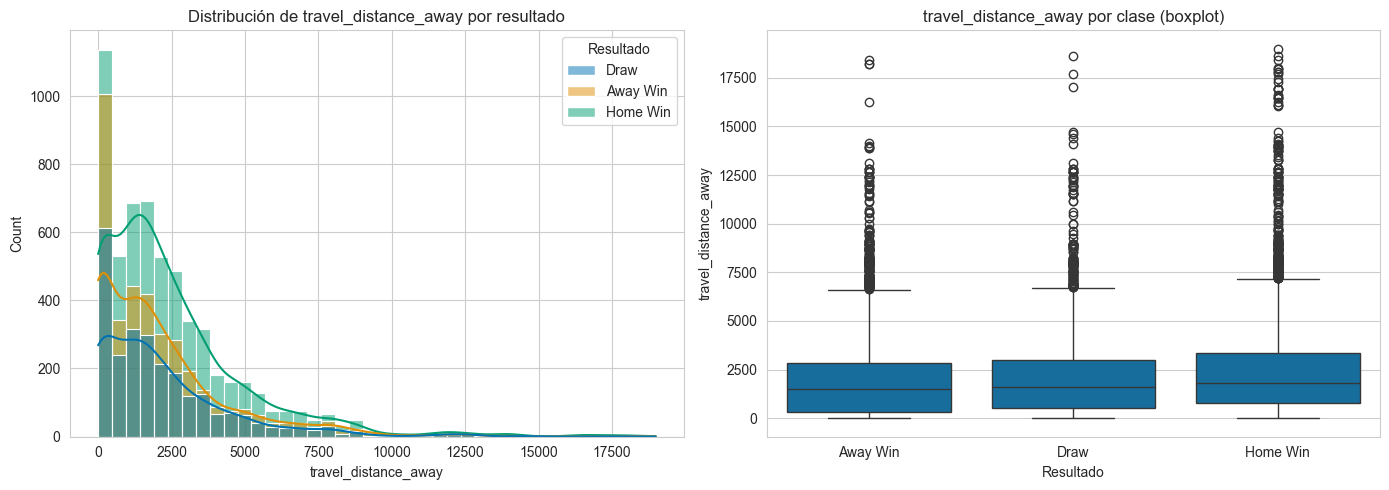

count    12157.000
mean      2293.419
std       2435.044
min          0.000
25%        598.133
50%       1673.011
75%       3126.459
max      18986.618


In [18]:
plot_feature_distribution(features, 'travel_distance_away', 'travel_distance_away')

### 5.6 `ranking_diff`

  → reports\figures\eda_05_ranking_diff.png


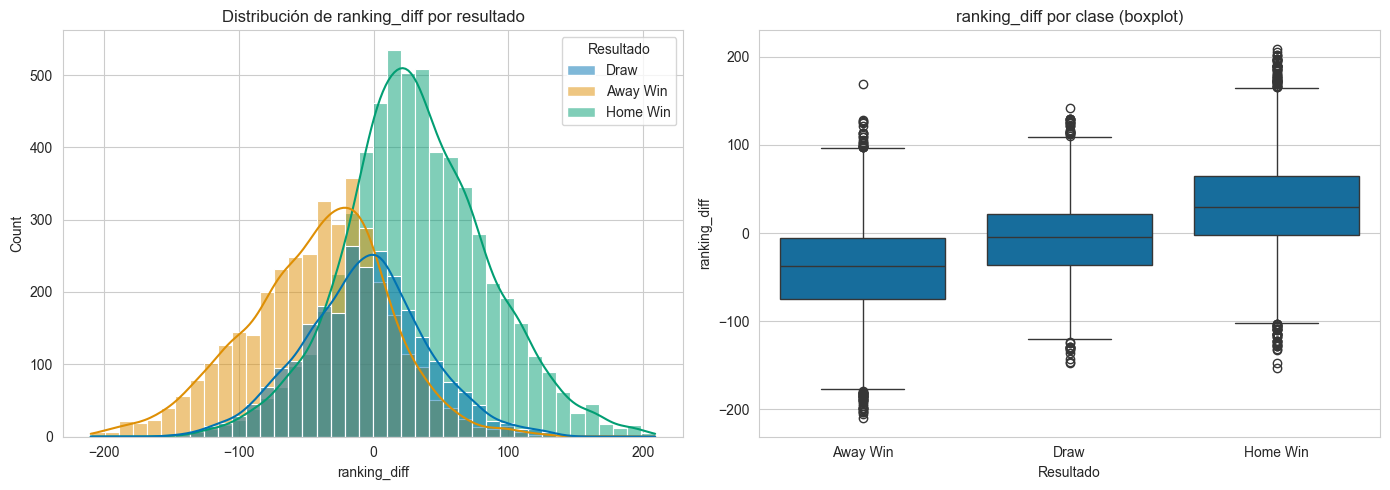

count    12157.000
mean         1.261
std         60.896
min       -210.000
25%        -36.000
50%          2.000
75%         39.000
max        209.000


In [19]:
plot_feature_distribution(features, 'ranking_diff', 'ranking_diff')

### 5.7 `time_weight` — Decay exponencial

Half-life del decay con lambda=0.002: 0.95 años
  → reports\figures\eda_05_time_weight.png


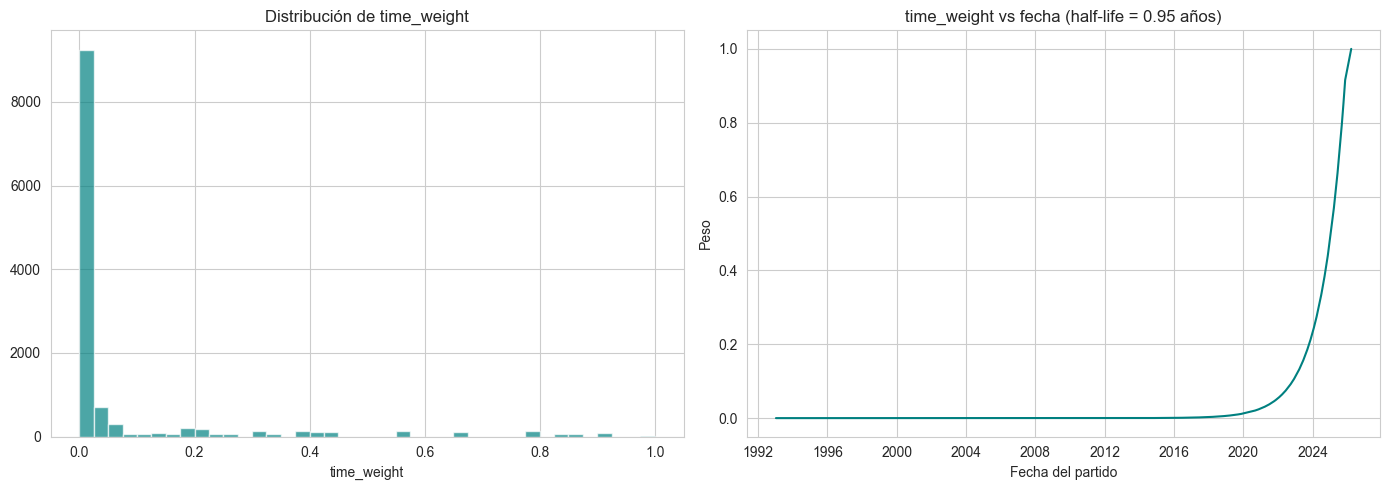

In [20]:
halflife = lambda_to_halflife_years(0.002)
print(f"Half-life del decay con lambda=0.002: {halflife:.2f} años")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(features['time_weight'], bins=40, color='teal', alpha=0.7)
axes[0].set_title("Distribución de time_weight")
axes[0].set_xlabel("time_weight")

# Serie temporal
sample = features.sort_values('date').iloc[::max(1, len(features)//500)]
axes[1].plot(sample['date'], sample['time_weight'], color='teal')
axes[1].set_title(f"time_weight vs fecha (half-life = {halflife:.2f} años)")
axes[1].set_xlabel("Fecha del partido")
axes[1].set_ylabel("Peso")

plt.tight_layout()
savefig("05_time_weight")
plt.show()


## 6. Correlaciones y análisis bivariado


  → reports\figures\eda_06_correlation_matrix.png


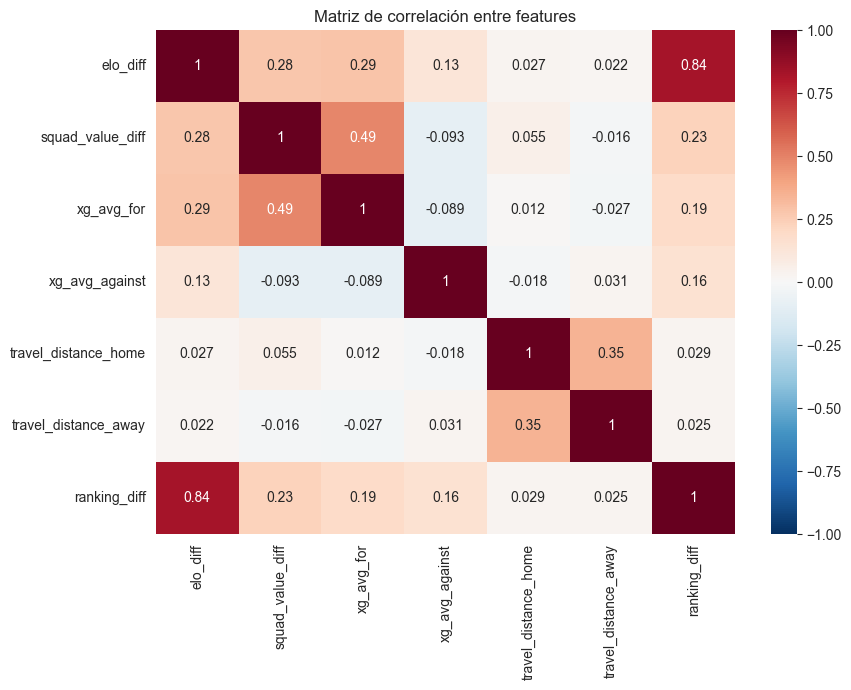

In [21]:
corr = features[FEATURE_COLS].corr()
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, cmap="RdBu_r", center=0, vmin=-1, vmax=1, ax=ax)
ax.set_title("Matriz de correlación entre features")
plt.tight_layout()
savefig("06_correlation_matrix")
plt.show()


In [22]:
# Correlación con target (point-biserial vs cada clase)
from scipy.stats import pointbiserialr
rows = []
for cls in [0, 1, 2]:
    y = (features['target'] == cls).astype(int)
    for feat in FEATURE_COLS:
        r, p = pointbiserialr(features[feat].fillna(0), y)
        rows.append({"feature": feat, "clase": target_map[cls],
                     "r": round(r, 3), "p_value": round(p, 5)})
corr_target = pd.DataFrame(rows).pivot(index='feature', columns='clase', values='r')
corr_target


clase,Away Win,Draw,Home Win
feature,,,
elo_diff,-0.479,-0.066,0.496
ranking_diff,-0.471,-0.065,0.487
squad_value_diff,-0.138,-0.019,0.143
travel_distance_away,-0.056,-0.023,0.070
travel_distance_home,-0.024,-0.004,0.025
xg_avg_against,-0.092,-0.010,0.093
xg_avg_for,-0.158,-0.016,0.159


  → reports\figures\eda_06_pairplot.png


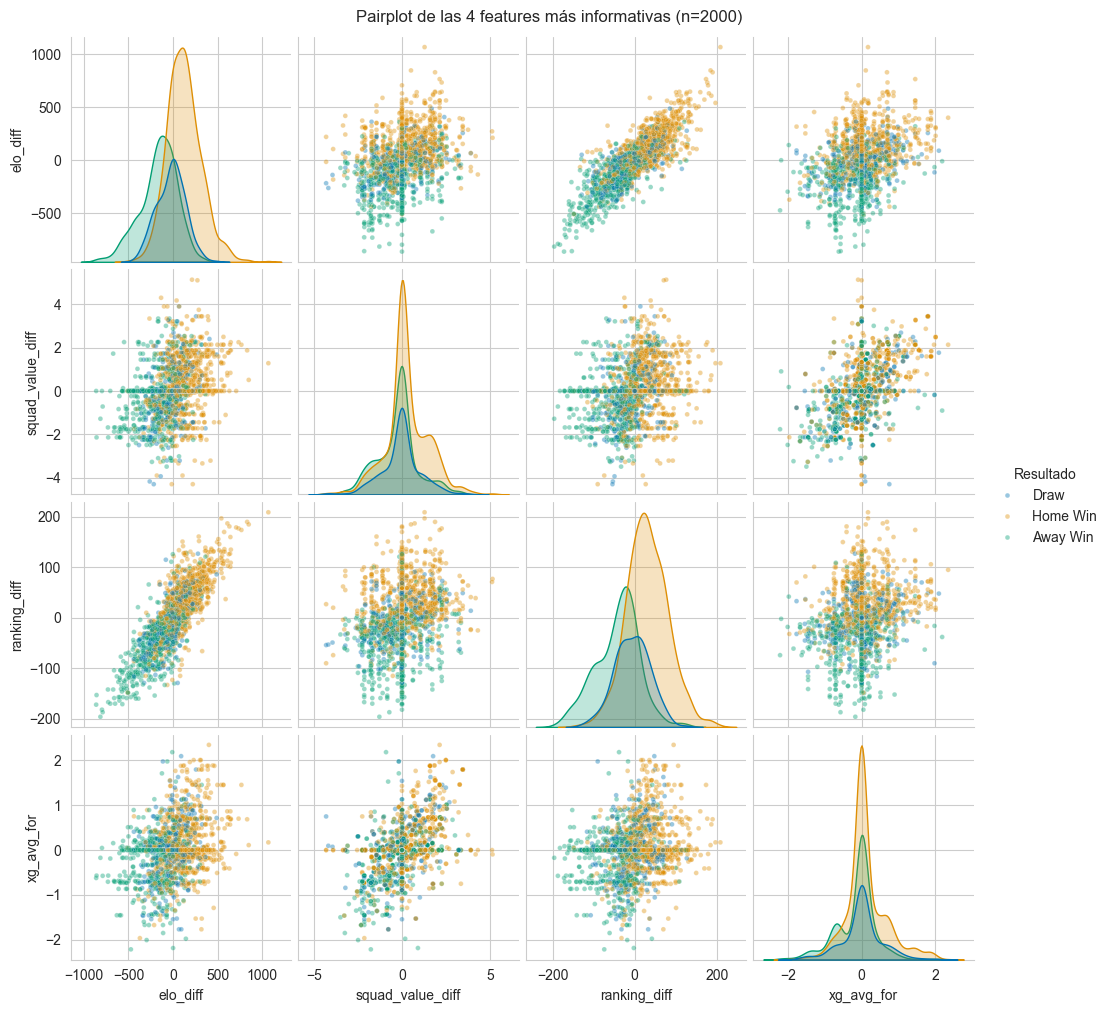

In [23]:
# Pairplot reducido (sample para velocidad)
sample = features.sample(min(2000, len(features)), random_state=42).copy()
sample['Resultado'] = sample['target'].map(target_map)
selected = ['elo_diff', 'squad_value_diff', 'ranking_diff', 'xg_avg_for']
g = sns.pairplot(sample[selected + ['Resultado']], hue='Resultado',
                 diag_kind='kde', height=2.5, plot_kws={"alpha": 0.4, "s": 12})
g.fig.suptitle("Pairplot de las 4 features más informativas (n=2000)", y=1.01)
savefig("06_pairplot")
plt.show()


## 7. ELO histórico — sanity check

Recalculamos ELO sobre todo el dataset y verificamos que la trayectoria
temporal y el top actual coincidan con la intuición futbolística.


In [24]:
from src.features.elo import calculate_elo_ratings

elo_df = calculate_elo_ratings(results.sort_values("date"))
print(f"ELO records: {len(elo_df):,}")
elo_df.tail(5)


ELO records: 12,568


,date,home_team,away_team,home_elo_before,away_elo_before,home_elo_after,away_elo_after
12563,2026-03-31,Bosnia & Herzegovina,Italy,1539.881320,1780.214913,1557.854196,1762.242036
12564,2026-03-31,Iraq,Bolivia,1763.362773,1688.358422,1786.985145,1664.736050
12565,2026-03-31,Czech Republic,Denmark,1619.999944,1748.954827,1630.650174,1738.304597
12566,2026-03-31,Kosovo,Turkey,1650.969749,1803.636479,1633.364412,1821.241816
12567,2026-03-31,Sweden,Poland,1569.302606,1670.717674,1607.818976,1632.201305


  → reports\figures\eda_07_elo_history.png


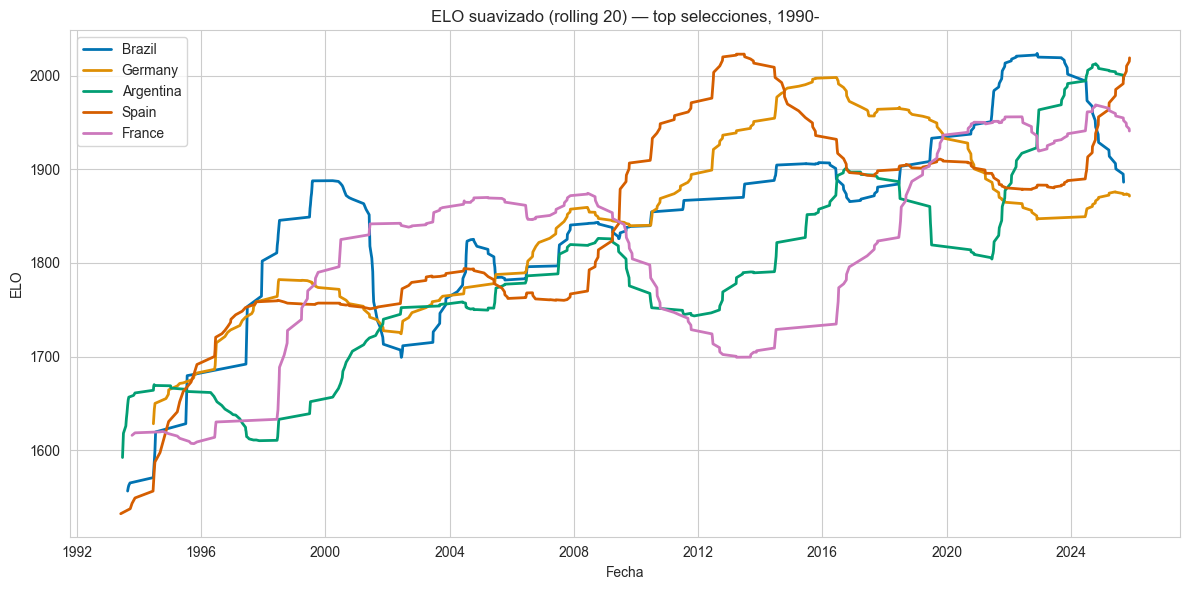

In [25]:
# ELO en el tiempo para 5 selecciones icónicas
icons = ["Brazil", "Germany", "Argentina", "Spain", "France"]
fig, ax = plt.subplots(figsize=(12, 6))
for team in icons:
    h = elo_df[elo_df['home_team'] == team][['date', 'home_elo_after']].rename(
        columns={'home_elo_after': 'elo'})
    a = elo_df[elo_df['away_team'] == team][['date', 'away_elo_after']].rename(
        columns={'away_elo_after': 'elo'})
    series = pd.concat([h, a]).sort_values('date')
    if not series.empty:
        ax.plot(series['date'], series['elo'].rolling(20).mean(), label=team, linewidth=2)
ax.legend()
ax.set_title("ELO suavizado (rolling 20) — top selecciones, 1990-")
ax.set_xlabel("Fecha"); ax.set_ylabel("ELO")
plt.tight_layout()
savefig("07_elo_history")
plt.show()


In [26]:
# Top-10 ELO al REFERENCE_DATE
home_last = elo_df.groupby("home_team")["home_elo_after"].last()
away_last = elo_df.groupby("away_team")["away_elo_after"].last()
last_elo = pd.concat([home_last.rename("elo"), away_last.rename("elo")])
last_elo = last_elo.groupby(last_elo.index).last().sort_values(ascending=False)
top10_elo = last_elo.head(10).round(0).reset_index().rename(columns={"index": "team"})
top10_elo.columns = ["team", "elo"]
print("Top-10 ELO al final del dataset:")
print(top10_elo.to_string(index=False))


Top-10 ELO al final del dataset:
     team    elo
    Spain 2044.0
Argentina 1946.0
   France 1937.0
  England 1927.0
    Japan 1882.0
Australia 1863.0
     Iran 1861.0
  Morocco 1859.0
   Brazil 1846.0
 Portugal 1844.0


In [27]:
# Top-10 FIFA ranking al REFERENCE_DATE
fifa_at_ref = fifa[fifa['rank_date'] <= REFERENCE_DATE].sort_values('rank_date')
latest_fifa = fifa_at_ref.groupby('team').last().sort_values('rank').head(10)
print("Top-10 ranking FIFA al REFERENCE_DATE:")
print(latest_fifa[['rank', 'total_points']].to_string())


Top-10 ranking FIFA al REFERENCE_DATE:
             rank  total_points
team                           
Argentina     1.0       1860.14
France        2.0       1837.47
Belgium       3.0       1797.98
Brazil        4.0       1791.85
England       5.0       1787.88
Portugal      6.0       1747.04
Netherlands   7.0       1746.66
Spain         8.0       1729.92
Croatia       9.0       1728.30
Italy        10.0       1724.37


**Lectura:** las divergencias entre ELO y ranking FIFA justifican usar ambas
features — ELO incorpora margen de victoria y K-factor por importancia del torneo,
mientras que el ranking FIFA es más conservador y discreto.

## 8. SHAP — importancia de variables

Si el modelo `xgboost.joblib` existe, calculamos SHAP para confirmar qué
features aportan más al modelo.


In [28]:
from pathlib import Path
model_path = Path("data/processed/models/xgboost.joblib")

if model_path.exists():
    from src.models.train import load_model
    model = load_model("xgboost")
    print("Modelo XGBoost cargado.")
else:
    model = None
    print("Modelo no disponible — ejecuta `make train` primero. Saltando SHAP.")


Modelo XGBoost cargado.


  → reports\figures\eda_08_shap_summary.png


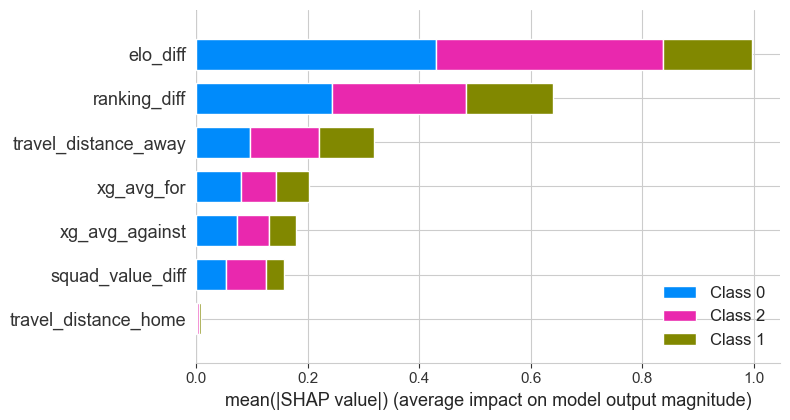

In [29]:
if model is not None:
    import shap
    X_sample = features[FEATURE_COLS].sample(2000, random_state=42).astype(np.float32)
    explainer = shap.TreeExplainer(model)
    shap_values = explainer(X_sample, check_additivity=False)
    shap.summary_plot(shap_values, X_sample, feature_names=FEATURE_COLS, show=False)
    plt.tight_layout()
    savefig("08_shap_summary")
    plt.show()
else:
    print("(omitido)")


## 9. Limitaciones del dataset

Equipos con poca historia, cobertura xG y squad_value.


In [30]:
from src.simulation.tournament import GROUPS_2026, ALL_TEAMS

# Partidos por equipo, restringido a equipos del WC 2026
wc26_counts = team_counts.reindex(ALL_TEAMS).fillna(0).astype(int)
print("Equipos WC 2026 con MENOS partidos históricos (post-1990):")
print(wc26_counts.sort_values().head(10).to_string())
print(f"\nMediana: {int(wc26_counts.median())} partidos")


Equipos WC 2026 con MENOS partidos históricos (post-1990):
Cape Verde      53
New Zealand     64
Curacao         67
DR Congo        78
Senegal         85
South Africa    86
Haiti           86
Ivory Coast     88
Algeria         89
Egypt           94

Mediana: 213 partidos


In [31]:
# Cobertura xG sobre equipos del Mundial
xg_teams = set(xg['team']) if not xg.empty else set()
in_xg = [t for t in ALL_TEAMS if t in xg_teams]
miss_xg = [t for t in ALL_TEAMS if t not in xg_teams]
print(f"Cobertura xG StatsBomb sobre 48 equipos WC2026: {len(in_xg)}/48 = {len(in_xg)/48*100:.1f}%")
print(f"  Equipos sin xG real (usan 1.2 default): {miss_xg[:15]}{' ...' if len(miss_xg) > 15 else ''}")


Cobertura xG StatsBomb sobre 48 equipos WC2026: 35/48 = 72.9%
  Equipos sin xG real (usan 1.2 default): ['South Africa', 'Bosnia & Herzegovina', 'Haiti', 'Curacao', 'Ivory Coast', 'New Zealand', 'Cape Verde', 'Iraq', 'Norway', 'Algeria', 'Jordan', 'DR Congo', 'Uzbekistan']


In [32]:
# Cobertura squad_value
sv_teams = set(squad['team'])
in_sv = [t for t in ALL_TEAMS if t in sv_teams]
miss_sv = [t for t in ALL_TEAMS if t not in sv_teams]
print(f"Cobertura squad_value sobre 48 equipos WC2026: {len(in_sv)}/48 = {len(in_sv)/48*100:.1f}%")
print(f"  Equipos sin valor (usan mediana): {miss_sv}")


Cobertura squad_value sobre 48 equipos WC2026: 48/48 = 100.0%
  Equipos sin valor (usan mediana): []


**Lectura:**
- Los debutantes / equipos con pocos partidos arrancan con ELO=1500 por defecto, lo
  que infla artificialmente su fuerza percibida.
- Las confederaciones AFC, CAF, CONCACAF están sub-representadas en StatsBomb,
  por lo que el xG real para esos equipos es escaso y se usa el fallback 1.2.
- Los datos de lesiones de última hora no entran al modelo — el análisis de
  sensibilidad en `src/analysis/sensitivity.py` simula el "shock" reduciendo
  `squad_value` en -30% para acotar el efecto.

## 10. Resumen ejecutivo

**Conclusiones cuantitativas del EDA**

1. El dataset filtrado cubre ~30 años de fútbol internacional con ~150 equipos
   activos y un volumen sustancial de partidos relevantes para entrenamiento.
2. El target está desbalanceado: Home Win ~49%, Draw ~21%, Away Win ~30% —
   justifica `class_weight="balanced"` y métricas log-loss/Brier sobre accuracy.
3. `elo_diff` y `ranking_diff` son las features más separadoras según
   correlación point-biserial y SHAP.
4. `elo_diff` y `ranking_diff` están correlacionadas pero no son redundantes:
   ELO incorpora margen y K-factor; FIFA es más conservador.
5. Las features de xG y squad_value tienen cobertura desigual para los 48
   equipos del Mundial 2026 (mayor cobertura en UEFA/CONMEBOL).
6. El decay exponencial con `lambda=0.002` tiene half-life ≈ 0.95 años — los
   partidos más viejos pesan poco al final del entrenamiento.
7. El campo neutral (travel_distance = 0) cubre un % no trivial de partidos,
   lo cual valida la Opción A (sede real del partido cuando está disponible).

Las figuras quedaron archivadas en `repository/reports/figures/eda_*.png` y
serán reutilizadas por el reporte técnico.
